<a href="https://colab.research.google.com/github/allythe/HorizonDetection/blob/main/Algorithms.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brief Outline

This document implements a pipeline for running multiple horizon detection methods on images, including:

- **H-HC**
- **H-LSC**
- **H-MED**
- **H-COV-LUM**
- **Segment**
- **DexiNed**

The code is organized into three main parts:

1. **Implementation of the algorithms** – defining all horizon detection methods.  
2. **Running the algorithms on a single image** – visualize results and adjust parameters.  
3. **Running the algorithms on all images** – process the full dataset and save predicted horizon coordinates to a CSV file.

In [1]:
import os
import time
import csv

import cv2
import numpy as np
import pandas as pd
import skimage
from skimage.color import rgb2gray
import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
from google.colab import drive
drive.mount("/content/drive/")
!ls /content/drive/MyDrive/MIUN/QRD/implementation/

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).
Algorithms.ipynb	     horizon_detection_h_cov_lum_results.csv  results
Analysis.ipynb		     horizon_detection_h_hc_results.csv       videos
DatasetFromCVAT.ipynb	     horizon_detection_h_lsc_results.csv
horizon_coordinates_all.csv  images


In [3]:
def get_image_type(filename):
    """Extract image type from filename"""
    if "boat_ice_1" in filename:
        return "boat_ice_1"
    elif "boat_ice_2" in filename:
        return "boat_ice_2"
    elif "boat_ice_3" in filename:
        return "boat_ice_3"
    elif "drone_ice_4" in filename:
        return "drone_ice_4"
    elif "drone_ice_5" in filename:
        return "drone_ice_5"
    elif "drone_ice_6" in filename:
        return "drone_ice_6"
    else:
        return None

# Implementation of the algorithms

## Edge detection and Hough transform based algorithm (H-HC)

The stages of this method can be summarized as follows:
1. Pre-process the image using morphological erosion to
 reduce the probability of the detection of weak edges
 in the later stages. A small circular structuring
 element can be used here. Alternatively, the image
 can be smoothed using a low pass filter, but we
 found erosion to provide better performance.
2. Apply Canny [3] edge detector to the pre-processed
 image.
3. Apply the Hough transform [4] to the edges map.
4. Choose the horizon line to be the longest line
 found in the previous step.

In [4]:
def h_hc_horizon_detection(path_or_img, img_types, img_type):
  if isinstance(path_or_img, str):
      img_rgb = skimage.io.imread(path_or_img)
  else:
      # Assume it's already an RGB NumPy array
      img_rgb = path_or_img

  img_grey = (rgb2gray(img_rgb) * 255).astype(np.uint8)

  # Step 1: Pre-process with morphological erosion using circular structuring element
  kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
  img_eroded = cv2.erode(img_grey, kernel, iterations=2)

  # Additional Gaussian blur to reduce ice texture noise
  kenrel_size = img_types[img_type]["gaussKernel"]
  img_processed = cv2.GaussianBlur(img_eroded, (kenrel_size, kenrel_size), 0)

  # 2 step - Canny detector for edges
  low = img_types[img_type]["canny"][0]
  high = img_types[img_type]["canny"][1]

  edges = cv2.Canny(img_processed,low,high)
  dilation_kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (5, 5))
  edges = cv2.dilate(edges, dilation_kernel, iterations=1)

  # Hough transform
  lines = cv2.HoughLinesP(
      edges,
      rho=1,
      theta=np.pi/180,
      threshold=100,
      minLineLength=50,
      maxLineGap=img_types[img_type]["maxLineGap"]
  )

  horizon_line = None
  max_length = 0

  # Create a copy of the image to draw lines
  img_lines = img_rgb.copy()

  if lines is not None:
      for line in lines:
          x1, y1, x2, y2 = line[0]

          height, width = img_grey.shape
          margin = 20  # Margin from image borders

          # Check if line is close to any image border (frame)
          is_frame_line = (
              (abs(x1) < margin or abs(x1 - width) < margin or
                abs(x2) < margin or abs(x2 - width) < margin) and
              (abs(y1) < margin or abs(y1 - height) < margin or
                abs(y2) < margin or abs(y2 - height) < margin)
          )

          # Skip lines that form the frame
          if is_frame_line:
              continue

          # Draw each line in green
          cv2.line(img_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

          # Find the longest line (optional, same as before)
          length = np.sqrt((x2 - x1)**2 + (y2 - y1)**2)
          if length > max_length:
              max_length = length
              horizon_line = (x1, y1, x2, y2)

      # Draw the longest line (horizon) in red
      if horizon_line:
          x1, y1, x2, y2 = horizon_line
          cv2.line(img_lines, (x1, y1), (x2, y2), (255, 0, 0), 3)

  return edges, horizon_line, img_lines

## Edge detection and least squares calibration based algorithm (H-LSC)

This algorithm is based on edge detection as well, but
uses a simple algorithm to detect the maximal vertical edge
in each column of the image. Its stages are described below.
1. Pre-process the image using morphological erosion.
2. Find the maximal vertical edge in each column of the
 image. The simplest way to measure the edge
 strength is using an approximation of the vertical
derivative, e.g.,
Y Y i j i j , 1,  
. Store the (i,j)
coordinates of the maximal edges.
3. Use the least squares method to find the optimal line
 passing throug the maximal edges’ coordinates.
 Edges with very small values as well as very big
 ones can be discarded here for better algorithm
  resilience to noise.

In [5]:
def h_lsc_horizon_detection(path, img_types, img_type):
    img_rgb = skimage.io.imread(path)

    img_grey = (rgb2gray(img_rgb) * 255).astype(np.uint8)

    # Step 1: Pre-process with morphological erosion using circular structuring element
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    img_eroded = cv2.erode(img_grey, kernel, iterations=2)

    # Additional Gaussian blur to reduce ice texture noise
    kernel_size = img_types[img_type]["gaussKernel"]
    img_processed = cv2.GaussianBlur(img_eroded, (kernel_size, kernel_size), 0)

    # Step 2: Find maximal vertical edge in each column - VECTORIZED
    height, width = img_processed.shape

    # Calculate vertical derivative (edge strength) using simple difference
    vertical_edges = np.zeros_like(img_processed, dtype=np.float32)
    vertical_edges[:-1, :] = img_processed[1:, :].astype(np.float32) - img_processed[:-1, :].astype(np.float32)

    # Take absolute value for edge strength
    edge_strength = np.abs(vertical_edges)

    margin = 20

    # Define the region of interest (exclude borders)
    col_start, col_end = margin, width - margin
    row_start, row_end = margin, height - margin

    # Extract the region of interest
    roi_edges = edge_strength[row_start:row_end, col_start:col_end]

    if roi_edges.size > 0:
        # Find max in each column (vectorized)
        max_rows_sliced = np.argmax(roi_edges, axis=0)
        max_strengths = roi_edges[max_rows_sliced, np.arange(roi_edges.shape[1])]

        # Convert back to original coordinates
        max_rows = max_rows_sliced + row_start
        max_cols = np.arange(col_start, col_end)

        # Apply threshold
        strength_threshold = img_types[img_type].get("edge_threshold", 10)
        valid_mask = max_strengths > strength_threshold

        max_edge_points = list(zip(max_cols[valid_mask], max_rows[valid_mask]))
        max_edge_strengths = max_strengths[valid_mask].tolist()
    else:
        max_edge_points = []
        max_edge_strengths = []

    horizon_line = None
    img_lines = img_rgb.copy()

    if len(max_edge_points) >= 2:
        points = np.array(max_edge_points)
        x_coords = points[:, 0]
        y_coords = points[:, 1]
        strengths = np.array(max_edge_strengths)

        if "strength_percentile" in img_types[img_type]:
            lower_p = img_types[img_type]["strength_percentile"][0]
            upper_p = img_types[img_type]["strength_percentile"][1]
        else:
            lower_p, upper_p = 10, 90

        lower_thresh = np.percentile(strengths, lower_p)
        upper_thresh = np.percentile(strengths, upper_p)

        valid_mask = (strengths >= lower_thresh) & (strengths <= upper_thresh)
        filtered_x = x_coords[valid_mask]
        filtered_y = y_coords[valid_mask]

        if len(filtered_x) >= 2:
            A = np.vstack([filtered_x, np.ones(len(filtered_x))]).T
            m, b = np.linalg.lstsq(A, filtered_y, rcond=None)[0]

            x1, x2 = 0, width - 1
            y1 = int(m * x1 + b)
            y2 = int(m * x2 + b)

            horizon_line = (x1, y1, x2, y2)

            for point in max_edge_points:
                cv2.circle(img_lines, point, 1, (255, 0, 0), -1)

            if horizon_line:
                cv2.line(img_lines, (x1, y1), (x2, y2), (255, 0, 0), 3)

    edges_vis = (edge_strength > img_types[img_type].get("edge_threshold", 10)).astype(np.uint8) * 255

    return edges_vis, horizon_line, img_lines

## Median Filtering and Linear Regression Based Algorithm (H-MED)

This algorithm employs median filters in several stages providing high performance in the presence of noise. The stages of the algorithm are:

1. Pre-processing
Pre-process the image using morphological erosion.

2. Maximal Vertical Edge Detection
Find the maximal vertical edge in each column of the image. Here the edge at pixel $(i,j)$ is measured as the absolute difference between two median values of the 5 pixels above and including pixel $(i,j)$ and the 5 pixels below it, i.e.,

$$
\text{edge}_{i,j} = |\text{med}_1 - \text{med}_2|
$$

where

$$
\begin{align*}
\text{med}_1 &= \text{median}\{Y_{k,j}\}_{k=i-4}^{i} \\
\text{med}_2 &= \text{median}\{Y_{k,j}\}_{k=i}^{i+4}
\end{align*}
$$

The $(i,j)$ coordinates of the maximal edges are stored.

3. Linear Regression
Use linear regression to find the optimal line passing through the maximal edges' coordinates.

In [6]:
def h_med_horizon_detection(path, img_types, img_type):
    img_rgb = skimage.io.imread(path)
    if img_rgb is None or len(img_rgb.shape) < 2:
        raise ValueError(f"Invalid image: {path}")

    offset = 50 if img_type == "drone_ice_4" else 2
    img_grey = (rgb2gray(img_rgb) * 255).astype(np.uint8)

    # Downsample for speed (adjust factor as needed)
    downsample_factor = img_types[img_type].get("downsample", 0.5)
    if downsample_factor < 1.0:
        img_grey = cv2.resize(img_grey, None, fx=downsample_factor, fy=downsample_factor, interpolation=cv2.INTER_AREA)

    # Morphological + Gaussian preprocessing
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    img_eroded = cv2.erode(img_grey, kernel, iterations=2)

    kernel_size = img_types[img_type]["gaussKernel"]
    img_processed = cv2.GaussianBlur(img_eroded, (kernel_size, kernel_size), 0)

    height, width = img_processed.shape

    # Compute rolling medians using convolution trick
    upper = cv2.medianBlur(img_processed, 9)
    lower = np.roll(upper, -4, axis=0)
    edge_strength = np.abs(upper.astype(np.float32) - lower.astype(np.float32))

    # Find maximal vertical edge in each column (vectorized)
    margin = max(5, offset)
    col_range = np.arange(width)
    roi = edge_strength[margin:height-margin, :]

    max_rows_sliced = np.argmax(roi, axis=0)
    max_strengths = roi[max_rows_sliced, col_range]
    max_rows = max_rows_sliced + margin

    # Apply edge threshold
    strength_threshold = img_types[img_type].get("edge_threshold", 5)
    valid_mask = max_strengths > strength_threshold
    x_coords = col_range[valid_mask]
    y_coords = max_rows[valid_mask]

    # Fit horizon line
    horizon_line = None
    img_lines = cv2.cvtColor(img_grey, cv2.COLOR_GRAY2BGR)

    if len(x_coords) >= 2:
        A = np.vstack([x_coords, np.ones(len(x_coords))]).T
        m, b = np.linalg.lstsq(A, y_coords, rcond=None)[0]
        x1, x2 = 0, width - 1
        y1 = int(m * x1 + b)
        y2 = int(m * x2 + b)
        horizon_line = (x1, y1, x2, y2)

        for (x, y) in zip(x_coords, y_coords):
            cv2.circle(img_lines, (int(x), int(y)), 1, (0, 255, 0), -1)
        cv2.line(img_lines, (x1, y1), (x2, y2), (255, 0, 0), 2)

    edges_vis = (edge_strength > strength_threshold).astype(np.uint8) * 255

    # Optional: upscale results to original size for visualization
    if downsample_factor < 1.0:
        edges_vis = cv2.resize(edges_vis, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_NEAREST)
        img_lines = cv2.resize(img_lines, (img_rgb.shape[1], img_rgb.shape[0]), interpolation=cv2.INTER_LINEAR)
        if horizon_line:
            x1, y1, x2, y2 = horizon_line
            scale = 1 / downsample_factor
            horizon_line = (int(x1 * scale), int(y1 * scale), int(x2 * scale), int(y2 * scale))

    return edges_vis, horizon_line, img_lines

## Regional Covariance Based Algorithm (H-COV-LUM)

An algorithm for horizon detection for remotely piloted Micro Air Vehicles was introduced in [5]. The algorithm receives an image taken from the air as input and searches for an optimal partition of the image into two regions: sky and ground (or sky and sea) using a line, which is the detected horizon.

### Mathematical Formulation

The optimization criterion is based on the determinants and the traces of the covariance matrices of the two regions.

If we denote a sky pixel by:

$$
\mathbf{x}_{i,j}^s = [R_{i,j}^s, G_{i,j}^s, B_{i,j}^s]^T
$$

where $R_{i,j}^s, G_{i,j}^s, B_{i,j}^s$ are the primary red, green and blue values at the pixel $(i,j)$, and we denote a ground pixel by:

$$
\mathbf{x}_{i,j}^g = [R_{i,j}^g, G_{i,j}^g, B_{i,j}^g]^T
$$

then the covariance matrices of the regions are given by:

$$
\begin{align*}
\Lambda_s &= \mathbb{E}[(\mathbf{x}_{i,j}^s - \boldsymbol{\mu}_s)(\mathbf{x}_{i,j}^s - \boldsymbol{\mu}_s)^T], \quad \boldsymbol{\mu}_s = \mathbb{E}[\mathbf{x}_{i,j}^s] \\
\Lambda_g &= \mathbb{E}[(\mathbf{x}_{i,j}^g - \boldsymbol{\mu}_g)(\mathbf{x}_{i,j}^g - \boldsymbol{\mu}_g)^T], \quad \boldsymbol{\mu}_g = \mathbb{E}[\mathbf{x}_{i,j}^g]
\end{align*}
$$

where $\mathbb{E}[\cdot]$ denotes the statistical mean.

### Optimization Criterion

The optimization criterion, considered for all possible horizon line orientations and positions and maximized, is given by:

$$
J = \frac{1}{\text{trace}(\Lambda_s)^2 + \text{trace}(\Lambda_g)^2 + \det(\Lambda_s) + \det(\Lambda_g)}
$$

where $\det(\cdot)$ denotes the determinant and $\text{trace}(\cdot)$ denotes the trace of the covariance matrices $\Lambda_s$ and $\Lambda_g$.

### Luminance-Based Simplification

We consider a similar criterion for the luminance image, thus the optimization term $J$ becomes:

$$
J_1 = \frac{1}{\text{var}(Y_s) + \text{var}(Y_g) + \text{var}^2(Y_s) + \text{var}^2(Y_g)}
$$

where $\text{var}(\cdot)$ stands for variance and $Y_s$, $Y_g$ are the luminance values of the sky and ground regions, respectively.

A simplified optimization criteria:

$$
J_2 = \frac{1}{\text{var}(Y_s) + \text{var}(Y_g)}
$$

can be used instead of the one in (2) with similar results.

In [7]:
def h_cov_lum_horizon_detection(path, img_types, img_type):
    img_rgb = skimage.io.imread(path)
    img_grey = (rgb2gray(img_rgb) * 255).astype(np.uint8)
    height, width = img_grey.shape

    angle_step = img_types[img_type].get("angle_step", 1)
    downscale_factor = img_types[img_type].get("downscale_factor", 1)
    angle_range = img_types[img_type].get("angle_range", (-45, 45))

    if downscale_factor > 1:
        new_width = width // downscale_factor
        new_height = height // downscale_factor
        img_working = cv2.resize(img_grey, (new_width, new_height))
        scale_factor = downscale_factor
    else:
        img_working = img_grey
        scale_factor = 1

    work_height, work_width = img_working.shape

    best_score = -np.inf
    best_angle = 0
    best_intercept = 0

    angles = np.arange(angle_range[0], angle_range[1] + 1, angle_step)

    for angle in angles:
        angle_rad = np.deg2rad(angle)
        m = np.tan(angle_rad) if abs(angle) > 1e-6 else 0

        max_intercept = work_height + abs(m * work_width)
        intercepts = np.arange(-max_intercept, max_intercept, 3)

        for intercept in intercepts:
            score = calculate_covariance_score(img_working, m, intercept, work_width, work_height)

            if score > best_score:
                best_score = score
                best_angle = angle
                best_intercept = intercept

    # Convert back to original coordinates
    if downscale_factor > 1:
        intercept_original = best_intercept * scale_factor
        m_original = best_angle  # Angle remains the same
    else:
        intercept_original = best_intercept
        m_original = best_angle

    # Calculate line endpoints
    x1, x2 = 0, width - 1
    m_rad = np.deg2rad(m_original)
    m_tan = np.tan(m_rad) if abs(m_original) > 1e-6 else 0

    y1 = int(m_tan * x1 + intercept_original)
    y2 = int(m_tan * x2 + intercept_original)

    # Clip to image bounds
    y1 = max(0, min(height - 1, y1))
    y2 = max(0, min(height - 1, y2))

    horizon_line = (x1, y1, x2, y2)

    # Create visualization
    img_lines = img_rgb.copy()
    if horizon_line is not None:
        x1, y1, x2, y2 = horizon_line
        cv2.line(img_lines, (x1, y1), (x2, y2), (255, 0, 0), 3)

        # Add information text
        cv2.putText(img_lines, f"Angle: {best_angle:.1f} deg", (10, 30),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)
        cv2.putText(img_lines, f"Intercept: {best_intercept:.1f}", (10, 60),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255, 255, 255), 2)

    edges_vis = np.zeros_like(img_grey)

    return edges_vis, horizon_line, img_lines

def calculate_covariance_score(img, m, b, width, height):
    y_coords, x_coords = np.mgrid[0:height, 0:width]
    line_values = m * x_coords + b

    sky_mask = y_coords < line_values
    ground_mask = ~sky_mask

    sky_pixels = img[sky_mask]
    ground_pixels = img[ground_mask]

    # Check if we have enough pixels in both regions
    min_pixels = max(10, width * height * 0.05)
    if len(sky_pixels) < min_pixels or len(ground_pixels) < min_pixels:
        return -np.inf

    # Calculate variances
    var_sky = np.var(sky_pixels) if len(sky_pixels) > 0 else 0
    var_ground = np.var(ground_pixels) if len(ground_pixels) > 0 else 0

    # Weight by region size (like original covariance approach)
    w_sky = len(sky_pixels) / (width * height)
    w_ground = len(ground_pixels) / (width * height)

    weighted_variance = w_sky * var_sky + w_ground * var_ground

    # Avoid division by zero
    if weighted_variance == 0:
        return -np.inf

    # Return score to maximize (inverse of variance)
    return 1.0 / weighted_variance

## Segmentational network based algorithm (Segment)


In [8]:
!pip install transformers

In [9]:
import torch
from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation

def segment_water_hrnet(image_path, model, hc_image_params, max_processing_size=512):
    image = cv2.imread(image_path)

    image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    original_h, original_w = image_rgb.shape[:2]

    scale = min(max_processing_size / original_h, max_processing_size / original_w)
    new_h, new_w = int(original_h * scale), int(original_w * scale)

    image_resized = cv2.resize(image_rgb, (new_w, new_h), interpolation=cv2.INTER_LINEAR)
    inputs = processor(images=image_resized, return_tensors="pt").to(device)

    with torch.no_grad():
        outputs = model(**inputs)
    logits = outputs.logits

    upsampled_logits = torch.nn.functional.interpolate(
        logits,
        size=(original_h, original_w),
        mode="bilinear",
        align_corners=False
    )

    predicted_mask = upsampled_logits.argmax(1).squeeze().cpu().numpy()
    water_mask = (predicted_mask == 21) | (predicted_mask == 26)
    water_mask_3channel = np.stack([water_mask.astype(np.uint8) * 255] * 3, axis=-1)

    edges, horizon, img_lines = h_hc_horizon_detection(water_mask_3channel, hc_image_params, "hrnet")

    return edges, horizon, img_lines

In [10]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "openmmlab/upernet-convnext-small"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForSemanticSegmentation.from_pretrained(model_name)

model.to(device)
model.eval()
None

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(
Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


## Edge detection network based algorithm (DexiNed)


In [11]:
!git clone https://github.com/xavysp/DexiNed.git
%cd DexiNed
!pip install kornia --quiet

fatal: destination path 'DexiNed' already exists and is not an empty directory.
/content/DexiNed


In [12]:
import kornia as K
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load DexiNed model once
edge_model = K.models.edge_detection.dexined.DexiNedBuilder.build(pretrained=True)
edge_model = edge_model.to(device).eval()

def detect_horizon_dexined(image_path, max_processing_size=512, edge_thresh=50,
                           hough_rho=1, hough_theta=np.pi/180, hough_threshold=80,
                           min_line_len=50, max_line_gap=30):
    # Load and resize image
    img = Image.open(image_path).convert("RGB")
    orig_w, orig_h = img.size
    scale = min(max_processing_size / orig_h, max_processing_size / orig_w)
    proc_w, proc_h = int(orig_w * scale), int(orig_h * scale)
    img_resized = img.resize((proc_w, proc_h))

    # Preprocess for DexiNed
    x = torch.nn.functional.interpolate(
        torch.tensor(np.array(img_resized)).permute(2,0,1).unsqueeze(0).float()/255.,
        size=(proc_h, proc_w),
        mode='bilinear',
        align_corners=False
    ).to(device)

    # Run DexiNed
    with torch.no_grad():
        out = edge_model(x)[-1]
    edge_map_resized = (out.squeeze().cpu().numpy() * 255).astype(np.uint8)

    # Resize edge map back to original size
    edge_map = cv2.resize(edge_map_resized, (orig_w, orig_h), interpolation=cv2.INTER_LINEAR)

    # Threshold edges
    _, edges_binary = cv2.threshold(edge_map, edge_thresh, 255, cv2.THRESH_BINARY)

    # Hough transform
    lines = cv2.HoughLinesP(edges_binary, rho=hough_rho, theta=hough_theta,
                            threshold=hough_threshold, minLineLength=min_line_len,
                            maxLineGap=max_line_gap)

    img_np = np.array(img).copy()
    orig_h, orig_w = img_np.shape[:2]

    longest_line = None
    max_length = 0
    ignore_border = 10

    if lines is not None:
        for line in lines:
            x1, y1, x2, y2 = line[0]

            # Skip lines touching the image border
            if (x1 <= ignore_border or y1 <= ignore_border or x2 <= ignore_border
                or y2 <= ignore_border or
                x1 >= orig_w-ignore_border or y1 >= orig_h-ignore_border
                or x2 >= orig_w-ignore_border or y2 >= orig_h-ignore_border):
                continue

            length = np.hypot(x2 - x1, y2 - y1)
            cv2.line(img_np, (x1, y1), (x2, y2), (0, 255, 0), 1)  # all lines green

            if length > max_length:
                max_length = length
                longest_line = (x1, y1, x2, y2)

    if longest_line:
        x1, y1, x2, y2 = longest_line
        cv2.line(img_np, (x1, y1), (x2, y2), (255, 0, 0), 3)  # horizon red
    else:
        longest_line = None

    return edge_map, longest_line, img_np

# Running the algorithms on a single image

 ## Compute H-HC horizon on one image

In [13]:
hc_image_params = {
    "boat_ice_1": {
        "canny": [0, 140],
        "maxLineGap": 30,
        "gaussKernel": 7,
    },
    "boat_ice_2": {
        "canny": [0, 20],
        "maxLineGap": 25,
        "gaussKernel": 15,
    },
    "boat_ice_3": {
        "canny": [0, 10],
        "maxLineGap": 25,
        "gaussKernel": 15,
    },
    "drone_ice_4": {
        "canny": [0, 40],
        "maxLineGap": 50,
        "gaussKernel": 7,
    },
    "drone_ice_5": {
        "canny": [0, 60],
        "maxLineGap": 30,
        "gaussKernel": 5,
    },
    "drone_ice_6": {
        "canny": [0, 40],
        "maxLineGap": 30,
        "gaussKernel": 5,
    },
    "hrnet": {
        "canny": [0, 10],
        "maxLineGap": 500,
        "gaussKernel": 1,
    },
}

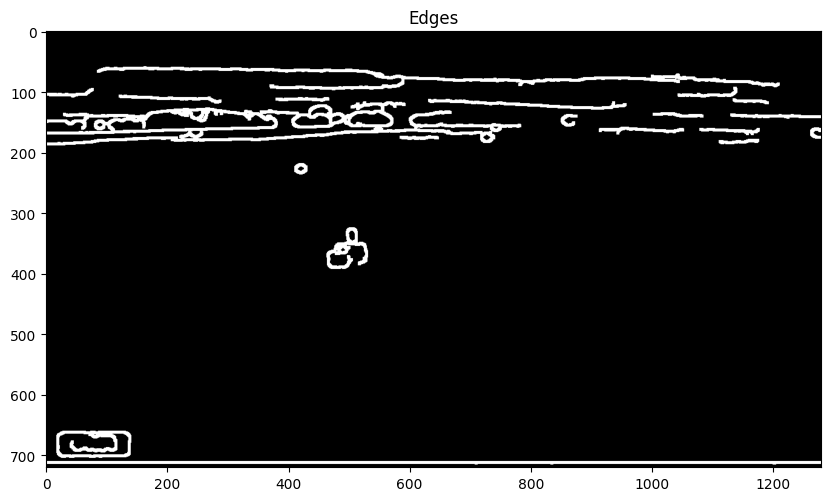

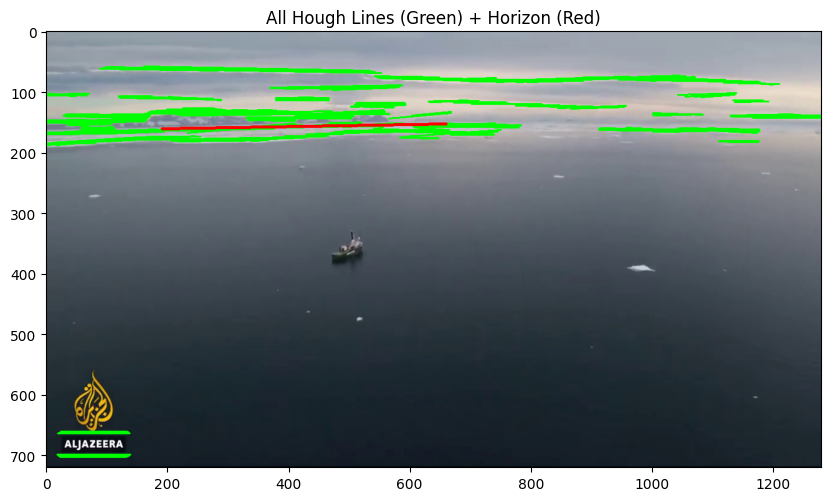

In [14]:
path = "/content/drive/MyDrive/MIUN/QRD/implementation/images/drone_ice_6_img_003590.jpeg"
edges, horizon, img_lines = h_hc_horizon_detection(path, hc_image_params,get_image_type(path))

# Show edges
plt.figure(figsize=(10,6))
plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.show()

# Show all lines + detected horizon
plt.figure(figsize=(10,6))
plt.imshow(img_lines)
plt.title("All Hough Lines (Green) + Horizon (Red)")
plt.show()

 ## Compute H-LSC horizon on one image

In [15]:
lsc_image_params = {
    "boat_ice_1": {
        "gaussKernel": 7,
        "edge_threshold": 15,
        "strength_percentile": [10, 90],
    },
    "boat_ice_2": {
        "gaussKernel": 7,
        "edge_threshold": 10,
        "strength_percentile": [10, 90],
    },
    "boat_ice_3": {
        "gaussKernel": 5,
        "edge_threshold": 15,
        "strength_percentile": [10, 90],
    },
    "drone_ice_4": {
        "gaussKernel": 5,
        "edge_threshold": 5,
        "strength_percentile": [10, 90],
    },
    "drone_ice_5": {
        "gaussKernel": 5,
        "edge_threshold": 5,
        "strength_percentile": [10, 90],
    },
    "drone_ice_6": {
        "gaussKernel": 5,
        "edge_threshold": 5,
        "strength_percentile": [10, 90],
    },
}

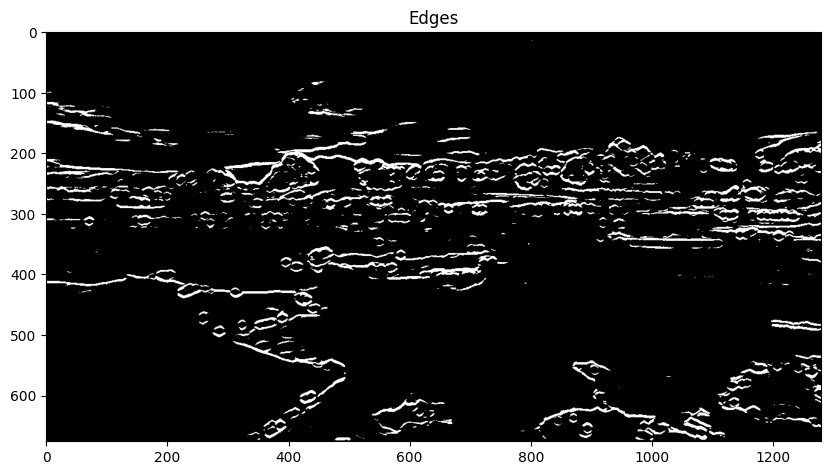

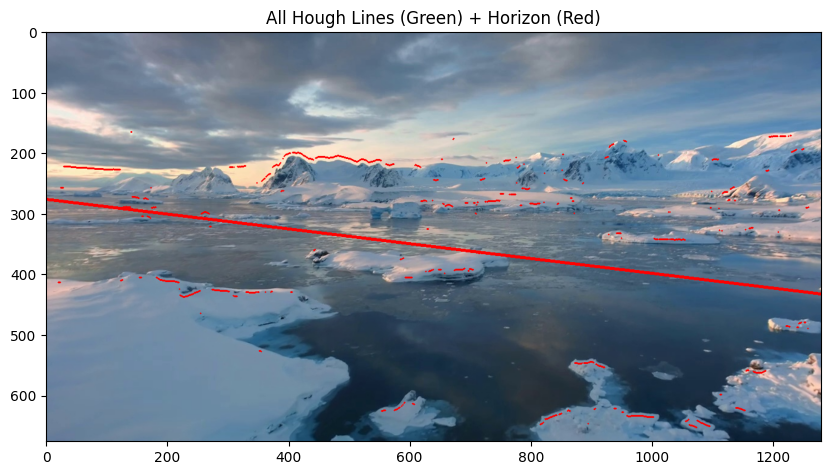

In [16]:
path = "/content/drive/MyDrive/MIUN/QRD/implementation/images/drone_ice_5_img_000760.jpeg"

edges, horizon, img_lines = h_lsc_horizon_detection(path, lsc_image_params, get_image_type(path))

# Show edges
plt.figure(figsize=(10,6))
plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.show()

# Show all lines + detected horizon
plt.figure(figsize=(10,6))
plt.imshow(img_lines)
plt.title("All Hough Lines (Green) + Horizon (Red)")
plt.show()

 ## Compute H-MED horizon on one image

In [17]:
h_med_image_params = {
    "boat_ice_1": {
        "gaussKernel": 7,
        "edge_threshold": 15,
    },
    "boat_ice_2": {
        "gaussKernel": 7,
        "edge_threshold": 15,
    },
    "boat_ice_3": {
        "gaussKernel": 5,
        "edge_threshold": 15,
    },
    "drone_ice_4": {
        "gaussKernel": 15,
        "edge_threshold": 5,
    },
    "drone_ice_5": {
        "gaussKernel": 15,
        "edge_threshold": 5,
    },
    "drone_ice_6": {
        "gaussKernel": 15,
        "edge_threshold": 5,
    },
}

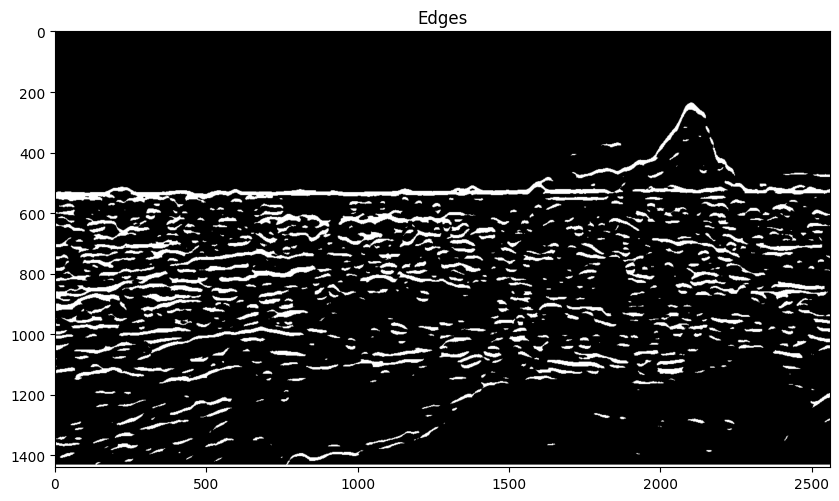

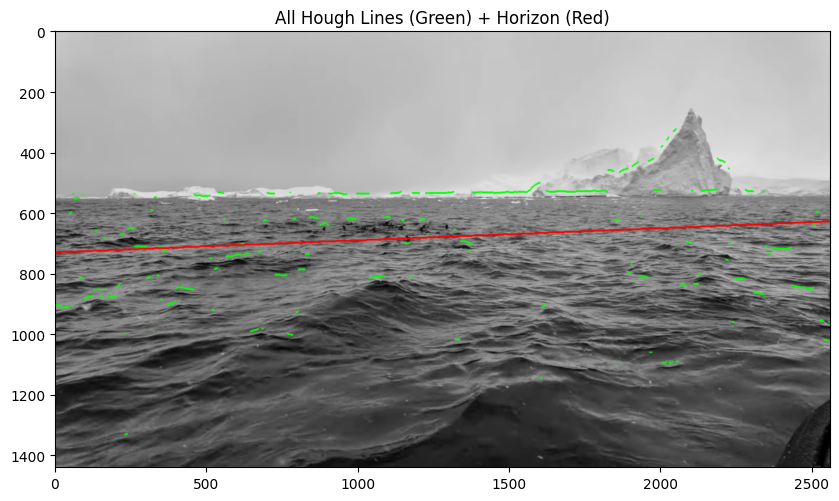

In [18]:
path = "/content/drive/MyDrive/MIUN/QRD/implementation/images/boat_ice_1_img_024910.jpeg"

edges, horizon, img_lines = h_med_horizon_detection(path, h_med_image_params, get_image_type(path))

# Show edges
plt.figure(figsize=(10,6))
plt.imshow(edges, cmap='gray')
plt.title("Edges")
plt.show()

# Show all lines + detected horizon
plt.figure(figsize=(10,6))
plt.imshow(img_lines)
plt.title("All Hough Lines (Green) + Horizon (Red)")
plt.show()

 ## Compute H-COV-LUM horizon on one image

In [19]:
h_cov_lum_image_params = {
    "boat_ice_1": {
        "downscale_factor": 10,
        "angle_step": 5,
    },
    "boat_ice_2": {
        "downscale_factor": 5,
        "angle_step": 5,
    },
    "boat_ice_3": {
        "downscale_factor": 10,
        "angle_step": 5,
    },
    "drone_ice_4": {
        "downscale_factor": 10,
        "angle_step": 5,
    },
    "drone_ice_5": {
        "downscale_factor": 5,
        "angle_step": 5,
    },
    "drone_ice_6": {
        "downscale_factor": 5,
        "angle_step": 5,
    },
}

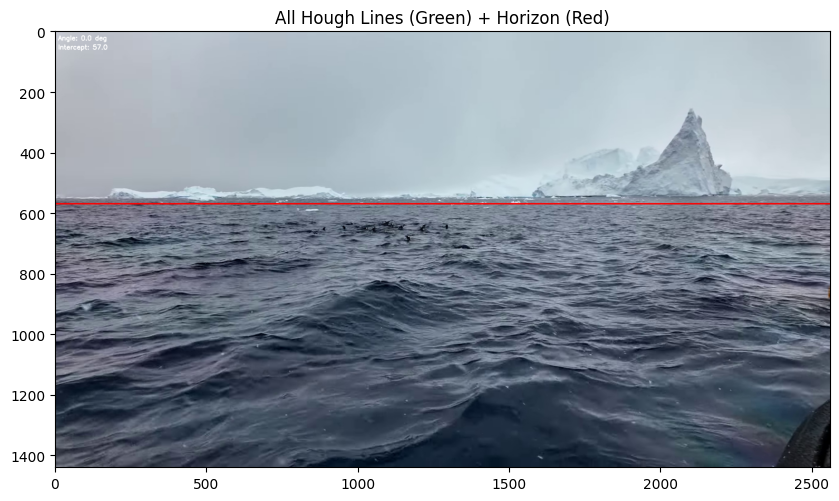

In [20]:
path = "/content/drive/MyDrive/MIUN/QRD/implementation/images/boat_ice_1_img_024910.jpeg"

edges, horizon, img_lines = h_cov_lum_horizon_detection(path, h_cov_lum_image_params, get_image_type(path) )

# Show all lines + detected horizon
plt.figure(figsize=(10,6))
plt.imshow(img_lines)
plt.title("All Hough Lines (Green) + Horizon (Red)")
plt.show()

 ## Compute Segment horizon on one image

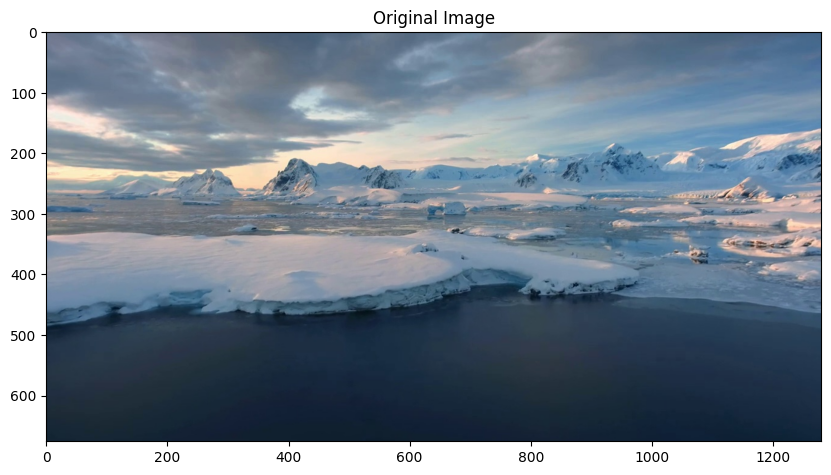

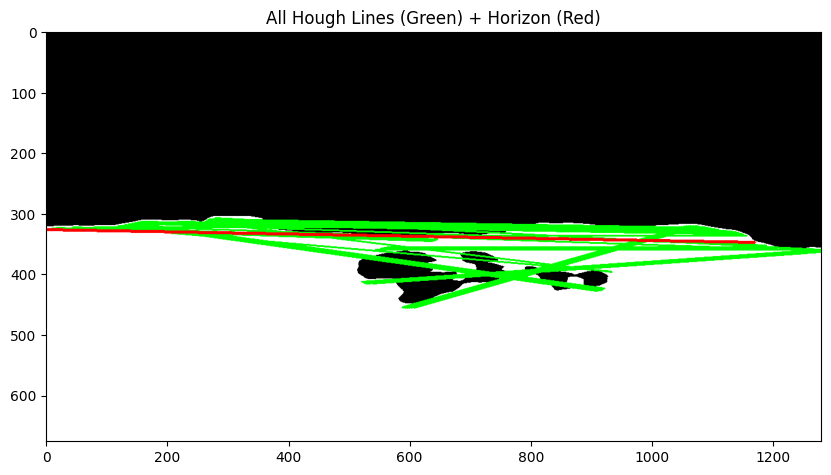

In [21]:
image_path = "/content/drive/MyDrive/MIUN/QRD/implementation/images/drone_ice_5_img_000168.jpeg"

edges, horizon, img_lines = segment_water_hrnet(image_path, model, hc_image_params)
img_rgb = skimage.io.imread(image_path)

# Show edges
plt.figure(figsize=(10,6))
plt.imshow(img_rgb)
plt.title("Original Image")
plt.show()

# Show all lines + detected horizon
plt.figure(figsize=(10,6))
plt.imshow(img_lines)
plt.title("All Hough Lines (Green) + Horizon (Red)")
plt.show()

 ## Compute DexiNed horizon on one image

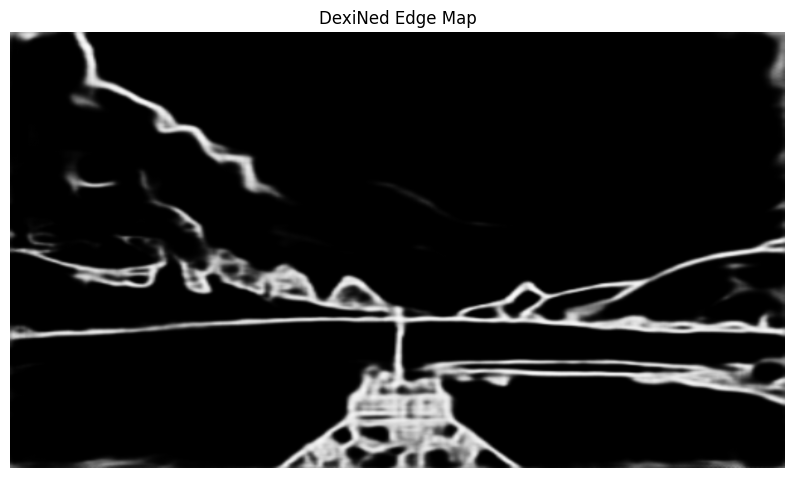

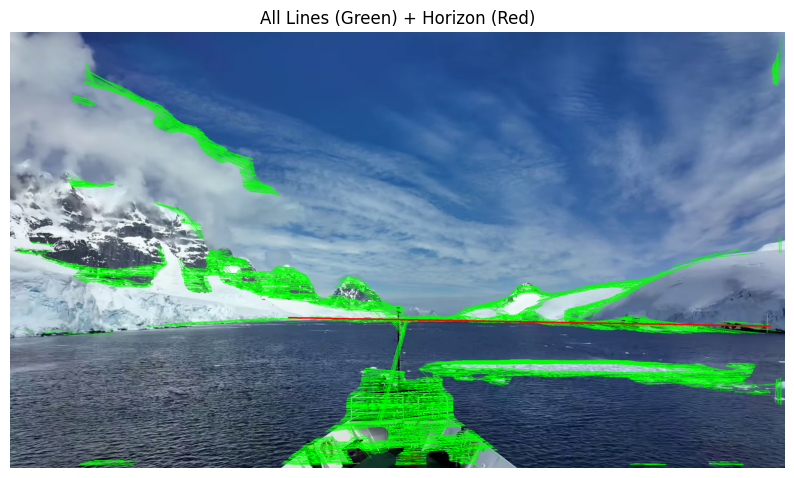

In [22]:
image_path = "/content/drive/MyDrive/MIUN/QRD/implementation/images/boat_ice_1_img_041840.jpeg"

edges, horizon, img_lines = detect_horizon_dexined(image_path)

plt.figure(figsize=(10,6))
plt.imshow(edges, cmap='gray')
plt.title("DexiNed Edge Map")
plt.axis('off')
plt.show()

plt.figure(figsize=(10,6))
plt.imshow(img_lines)
plt.title("All Lines (Green) + Horizon (Red)")
plt.axis('off')
plt.show()

# Running the algorithms on all images

## Run H-HC on all images and save results

In [23]:
def run_save_results(horizon_detection, image_params,  images_folder, method = "nohrnet", model = None):
    results = []

    for filename in tqdm(os.listdir(images_folder)):
        if not filename.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        img_path = os.path.join(images_folder, filename)

        start_time = time.time()
        if get_image_type(img_path) is None:
          continue

        if method == "hrnet":
          edges, horizon, img_lines = segment_water_hrnet(img_path, model, image_params)
        elif method == "dexined":
          edges, horizon, img_lines = detect_horizon_dexined(img_path)

        else:
          edges, horizon, img_lines = horizon_detection(img_path, image_params, get_image_type(img_path))
        elapsed = time.time() - start_time

        if horizon:
            x1, y1, x2, y2 = horizon
        else:
            x1 = y1 = x2 = y2 = None

        results.append({
            "image_name": filename,
            "x1": x1,
            "y1": y1,
            "x2": x2,
            "y2": y2,
            "time_sec": round(elapsed, 3)
        })
    return results

In [24]:
images_folder = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
output_csv = "/content/drive/MyDrive/MIUN/QRD/implementation/results/horizon_hc_orig_results.csv"

results =  run_save_results(h_hc_horizon_detection, hc_image_params,  images_folder)

# Save results to CSV
csv_path = output_csv
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["image_name", "x1", "y1", "x2", "y2", "time_sec"])
    writer.writeheader()
    writer.writerows(results)

print(f"Horizon detection completed for {len(results)} images.")
print(f"Results saved to: {csv_path}")

  1%|          | 8/707 [00:03<04:27,  2.61it/s]


KeyboardInterrupt: 

## Run H-LSC on all images and save results

In [25]:
images_folder = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
output_csv = "/content/drive/MyDrive/MIUN/QRD/implementation/results/horizon_h_lsc_results.csv"

results =  run_save_results(h_lsc_horizon_detection, lsc_image_params,  images_folder)

# Save results to CSV
csv_path = output_csv
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["image_name", "x1", "y1", "x2", "y2", "time_sec"])
    writer.writeheader()
    writer.writerows(results)

print(f"Horizon detection completed for {len(results)} images.")
print(f"Results saved to: {csv_path}")

  6%|▌         | 40/707 [00:02<00:34, 19.15it/s]


KeyboardInterrupt: 

## Run H-MED on all images and save results

In [26]:
images_folder = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
output_csv = "/content/drive/MyDrive/MIUN/QRD/implementation/results/horizon_h_med_results.csv"

results =  run_save_results(h_med_horizon_detection, h_med_image_params,  images_folder)

# Save results to CSV
csv_path = output_csv
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["image_name", "x1", "y1", "x2", "y2", "time_sec"])
    writer.writeheader()
    writer.writerows(results)

print(f"Horizon detection completed for {len(results)} images.")
print(f"Results saved to: {csv_path}")

  1%|▏         | 9/707 [00:01<02:04,  5.61it/s]


KeyboardInterrupt: 

## Run H-COV-LUM on all images and save results

In [27]:
images_folder = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
output_csv = "/content/drive/MyDrive/MIUN/QRD/implementation/results/horizon_h_cov_lum_results.csv"

results =  run_save_results(h_cov_lum_horizon_detection, h_cov_lum_image_params,  images_folder)

# Save results to CSV
csv_path = output_csv
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["image_name", "x1", "y1", "x2", "y2", "time_sec"])
    writer.writeheader()
    writer.writerows(results)

print(f"Horizon detection completed for {len(results)} images.")
print(f"Results saved to: {csv_path}")

  1%|          | 4/707 [00:18<53:15,  4.54s/it]


KeyboardInterrupt: 

## Run Segment on all images and save results

In [28]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

model_name = "openmmlab/upernet-convnext-small"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForSemanticSegmentation.from_pretrained(model_name)

model.to(device)
model.eval()

images_folder = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
output_csv = "/content/drive/MyDrive/MIUN/QRD/implementation/results/horizon_segment_results.csv"

results = run_save_results(segment_water_hrnet, hc_image_params, images_folder, "hrnet", model)

# Save results to CSV
csv_path = output_csv
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["image_name", "x1", "y1", "x2", "y2", "time_sec"])
    writer.writeheader()
    writer.writerows(results)

print(f"Horizon detection completed for {len(results)} images.")
print(f"Results saved to: {csv_path}")

Using device: cuda


  1%|▏         | 9/707 [00:01<02:32,  4.57it/s]


KeyboardInterrupt: 

## Run DexiNed on all images and save results

In [29]:
images_folder = "/content/drive/MyDrive/MIUN/QRD/implementation/images"
output_csv = "/content/drive/MyDrive/MIUN/QRD/implementation/results/horizon_dexined_results.csv"

results =  run_save_results(detect_horizon_dexined, hc_image_params, images_folder, "dexined")

# Save results to CSV
csv_path = output_csv
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["image_name", "x1", "y1", "x2", "y2", "time_sec"])
    writer.writeheader()
    writer.writerows(results)

print(f"Horizon detection completed for {len(results)} images.")
print(f"Results saved to: {csv_path}")

  0%|          | 2/707 [00:03<17:37,  1.50s/it]


KeyboardInterrupt: 